In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import os
import joblib

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import pandas as pd

df = pd.read_csv("cleaned_pharma_sales.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

display(df.head())

Shape: (80648, 18)

Columns:
['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel', 'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep', 'Manager', 'Sales Team']

Data types:
Distributor           object
Customer Name         object
City                  object
Country               object
Latitude             float64
Longitude            float64
Channel               object
Sub-channel           object
Product Name          object
Product Class         object
Quantity             float64
Price                  int64
Sales                float64
Month                 object
Year                 float64
Name of Sales Rep     object
Manager               object
Sales Team            object
dtype: object

Missing values:
Distributor          0
Customer Name        0
City                 0
Country              0
Latitude             0
Longitude            0
Channel              0
Sub-channel    

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018.0,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018.0,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018.0,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018.0,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018.0,Anne Wu,Britanny Bold,Delta


In [3]:
df = df.dropna(subset=["Customer Name", "Month", "Year"]).copy()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (80647, 18)


In [4]:
print(df["Month"].unique())

['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']


In [5]:

# Convert Year to integer
df["Year"] = df["Year"].astype(int)

# Create proper date
df["Date"] = pd.to_datetime(
    df["Month"] + " " + df["Year"].astype(str),
    format="%B %Y"
)

print(df[["Month", "Year", "Date"]].head())
print("\nDate range:")
print(df["Date"].min(), "→", df["Date"].max())

     Month  Year       Date
0  January  2018 2018-01-01
1  January  2018 2018-01-01
2  January  2018 2018-01-01
3  January  2018 2018-01-01
4  January  2018 2018-01-01

Date range:
2017-01-01 00:00:00 → 2018-12-01 00:00:00


In [6]:
# Reference date = one month after the latest transaction
reference_date = df["Date"].max() + pd.DateOffset(months=1)

customer_features = df.groupby("Customer Name").agg(
    Recency=("Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Date", "count"),
    Monetary=("Sales", "sum"),
    Product_Diversity=("Product Name", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Average_Order_Value=("Sales", "mean")
).reset_index()

customer_features.head()

,Customer Name,Recency,Frequency,Monetary,Product_Diversity,Total_Quantity,Average_Order_Value
0,Abernathy Group,487,74,8383539.0,67,16389.0,113291.067568
1,Abernathy Group Pharmaceutical Limited,31,223,2079222.0,151,5490.0,9323.865471
2,Abernathy Group Pharmacy,487,70,1955038.0,57,5411.0,27929.114286
3,Abernathy and Sons,487,72,2232858.0,64,11102.0,31011.916667
4,Abernathy and Sons Pharmaceutical Limited,487,85,2392265.0,71,5880.0,28144.294118


In [7]:
print("Number of customers:", len(customer_features))
print("\nShape:", customer_features.shape)

display(customer_features.head(10))

Number of customers: 751

Shape: (751, 7)


,Customer Name,Recency,Frequency,Monetary,Product_Diversity,Total_Quantity,Average_Order_Value
0,Abernathy Group,487,74,8383539.0,67,16389.0,113291.067568
1,Abernathy Group Pharmaceutical Limited,31,223,2079222.0,151,5490.0,9323.865471
2,Abernathy Group Pharmacy,487,70,1955038.0,57,5411.0,27929.114286
3,Abernathy and Sons,487,72,2232858.0,64,11102.0,31011.916667
4,Abernathy and Sons Pharmaceutical Limited,487,85,2392265.0,71,5880.0,28144.294118
5,Armstrong Inc Pharm,487,71,3363069.0,62,6973.0,47367.169014
6,Armstrong Inc Pharma Plc,487,89,2463546.0,70,7509.0,27680.292135
7,"Armstrong, Medhurst and Bogisich Pharmaceutica...",487,70,2342618.0,62,4431.0,33465.971429
8,"Armstrong, Medhurst and Bogisich Pharmacy",487,66,2956914.0,54,5756.0,44801.727273
9,Balistreri Group Pharm,487,66,1651616.0,57,3841.0,25024.484848


In [8]:
customer_features[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Product_Diversity",
        "Total_Quantity",
        "Average_Order_Value"
    ]
].describe()

,Recency,Frequency,Monetary,Product_Diversity,Total_Quantity,Average_Order_Value
count,751.000000,751.000000,7.510000e+02,751.000000,751.000000,751.000000
mean,365.974700,107.386152,3.342635e+06,82.474035,8139.671508,37691.455801
std,201.979605,58.299754,1.802356e+06,33.476066,3769.946448,25480.160197
min,31.000000,51.000000,4.947660e+05,44.000000,2372.000000,6262.860759
25%,31.000000,69.000000,2.257963e+06,59.500000,5746.000000,20595.185792
50%,487.000000,77.000000,2.968681e+06,66.000000,7320.000000,31531.250000
75%,487.000000,181.500000,3.894115e+06,125.000000,9488.000000,46225.022639
max,518.000000,239.000000,1.986231e+07,155.000000,40549.000000,233674.270588


In [9]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Product_Diversity",
    "Total_Quantity",
    "Average_Order_Value"
]

X = customer_features[features].copy()

print(X.isnull().sum())

Recency                0
Frequency              0
Monetary               0
Product_Diversity      0
Total_Quantity         0
Average_Order_Value    0
dtype: int64


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (751, 6)


In [11]:
k_values = range(2, 8)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k} → Silhouette Score={score:.4f}")

K=2 → Silhouette Score=0.6250
K=3 → Silhouette Score=0.6599
K=4 → Silhouette Score=0.5501
K=5 → Silhouette Score=0.5426
K=6 → Silhouette Score=0.4712
K=7 → Silhouette Score=0.3922


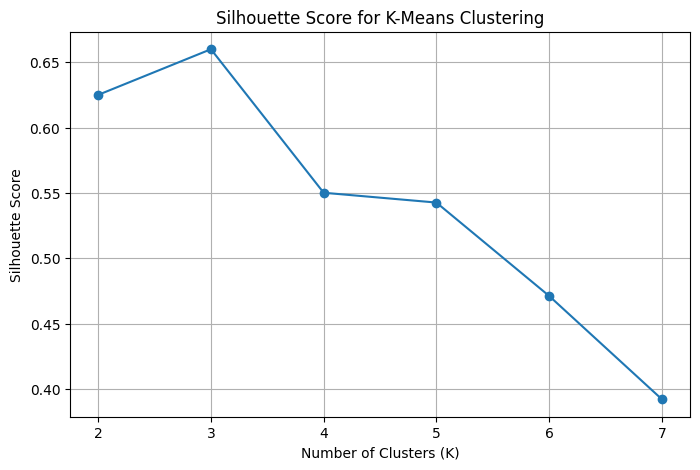

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means Clustering")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [13]:
# Train final K-Means model with optimal K
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_features["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means training completed!")
print("\nCluster distribution:")
print(customer_features["Cluster"].value_counts().sort_index())

K-Means training completed!

Cluster distribution:
Cluster
0    482
1    200
2     69
Name: count, dtype: int64


In [14]:
cluster_summary = customer_features.groupby("Cluster")[features].mean().round(2)

display(cluster_summary)

,Recency,Frequency,Monetary,Product_Diversity,Total_Quantity,Average_Order_Value
Cluster,,,,,,
0,487.45,72.33,2748942.63,62.43,6886.96,38079.69
1,31.00,202.42,3404379.71,136.58,8371.62,16815.33
2,488.35,76.86,7310908.17,65.67,16218.20,95489.97


In [15]:
cluster_counts = customer_features["Cluster"].value_counts().sort_index()

display(cluster_counts)

,count
Cluster,
0,482
1,200
2,69


In [16]:
cluster_labels = {
    0: "Low Engagement",
    1: "Loyal Active",
    2: "High Value At Risk"
}

customer_features["Segment"] = customer_features["Cluster"].map(cluster_labels)

display(
    customer_features[
        ["Customer Name", "Cluster", "Segment"] + features
    ].head(20)
)

,Customer Name,Cluster,Segment,Recency,Frequency,Monetary,Product_Diversity,Total_Quantity,Average_Order_Value
0,Abernathy Group,2,High Value At Risk,487,74,8383539.0,67,16389.0,113291.067568
1,Abernathy Group Pharmaceutical Limited,1,Loyal Active,31,223,2079222.0,151,5490.0,9323.865471
2,Abernathy Group Pharmacy,0,Low Engagement,487,70,1955038.0,57,5411.0,27929.114286
3,Abernathy and Sons,0,Low Engagement,487,72,2232858.0,64,11102.0,31011.916667
4,Abernathy and Sons Pharmaceutical Limited,0,Low Engagement,487,85,2392265.0,71,5880.0,28144.294118
5,Armstrong Inc Pharm,0,Low Engagement,487,71,3363069.0,62,6973.0,47367.169014
6,Armstrong Inc Pharma Plc,0,Low Engagement,487,89,2463546.0,70,7509.0,27680.292135
7,"Armstrong, Medhurst and Bogisich Pharmaceutica...",0,Low Engagement,487,70,2342618.0,62,4431.0,33465.971429
8,"Armstrong, Medhurst and Bogisich Pharmacy",0,Low Engagement,487,66,2956914.0,54,5756.0,44801.727273
9,Balistreri Group Pharm,0,Low Engagement,487,66,1651616.0,57,3841.0,25024.484848


In [17]:
print(
    customer_features["Segment"].value_counts()
)

Segment
Low Engagement        482
Loyal Active          200
High Value At Risk     69
Name: count, dtype: int64


In [18]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

In [19]:
customer_segments = customer_features[
    [
        "Customer Name",
        "Cluster",
        "Segment",
        "Recency",
        "Frequency",
        "Monetary",
        "Product_Diversity",
        "Total_Quantity",
        "Average_Order_Value"
    ]
].copy()

customer_segments.to_csv(
    "outputs/customer_segments.csv",
    index=False
)

print("Saved: outputs/customer_segments.csv")

Saved: outputs/customer_segments.csv


In [20]:
joblib.dump(
    kmeans,
    "models/customer_kmeans.pkl"
)

joblib.dump(
    scaler,
    "models/customer_scaler.pkl"
)

print("K-Means model saved!")
print("Scaler saved!")

K-Means model saved!
Scaler saved!


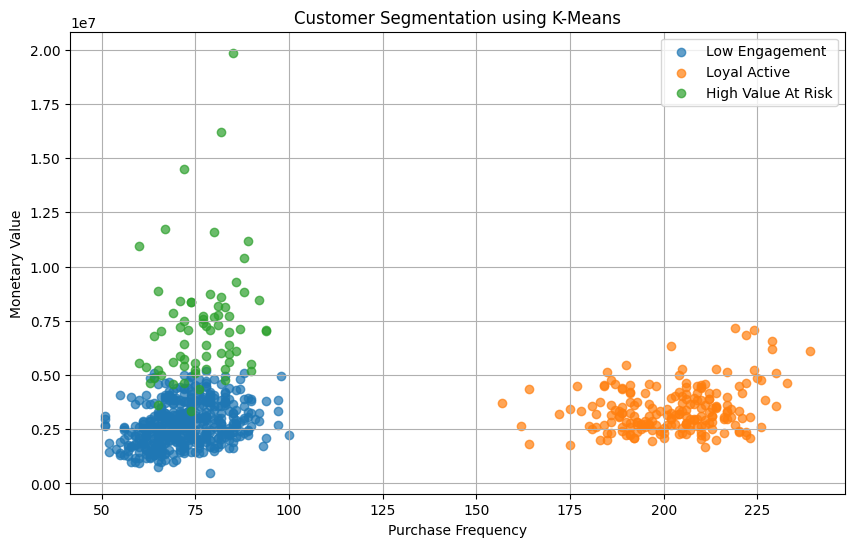

In [21]:
plt.figure(figsize=(10, 6))

for cluster in sorted(customer_features["Cluster"].unique()):
    cluster_data = customer_features[
        customer_features["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Frequency"],
        cluster_data["Monetary"],
        label=cluster_labels[cluster],
        alpha=0.7
    )

plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
plt.savefig(
    "visualizations/customer_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [24]:
monthly_sales = (
    df.groupby(["Year", "Month"], as_index=False)["Sales"]
    .sum()
)

print(monthly_sales.shape)

display(monthly_sales.head(20))

(21, 3)


,Year,Month,Sales
0,2017,April,1.887998e+08
1,2017,August,2.338347e+08
2,2017,February,2.089959e+08
3,2017,January,1.518722e+08
4,2017,July,2.604888e+08
5,2017,June,2.666684e+08
6,2017,March,2.147680e+08
7,2017,May,2.236348e+08
8,2017,September,8.038051e+07
9,2018,April,3.636135e+07


In [25]:
product_monthly = (
    df.groupby(
        ["Product Name", "Year", "Month"],
        as_index=False
    )["Sales"]
    .sum()
)

print("Shape:", product_monthly.shape)

display(product_monthly.head(20))

Shape: (5040, 4)


,Product Name,Year,Month,Sales
0,Abatatriptan,2017,April,1046220.0
1,Abatatriptan,2017,August,2484958.0
2,Abatatriptan,2017,February,335384.0
3,Abatatriptan,2017,January,1590848.0
4,Abatatriptan,2017,July,1012830.0
5,Abatatriptan,2017,June,591374.0
6,Abatatriptan,2017,March,1777090.0
7,Abatatriptan,2017,May,2507960.0
8,Abatatriptan,2017,September,1599752.0
9,Abatatriptan,2018,April,143206.0


In [26]:
product_monthly["Date"] = pd.to_datetime(
    product_monthly["Month"] + " " +
    product_monthly["Year"].astype(int).astype(str),
    format="%B %Y"
)

product_monthly = product_monthly.sort_values(
    ["Product Name", "Date"]
).reset_index(drop=True)

display(product_monthly.head(20))

,Product Name,Year,Month,Sales,Date
0,Abatatriptan,2017,January,1590848.0,2017-01-01
1,Abatatriptan,2017,February,335384.0,2017-02-01
2,Abatatriptan,2017,March,1777090.0,2017-03-01
3,Abatatriptan,2017,April,1046220.0,2017-04-01
4,Abatatriptan,2017,May,2507960.0,2017-05-01
5,Abatatriptan,2017,June,591374.0,2017-06-01
6,Abatatriptan,2017,July,1012830.0,2017-07-01
7,Abatatriptan,2017,August,2484958.0,2017-08-01
8,Abatatriptan,2017,September,1599752.0,2017-09-01
9,Abatatriptan,2018,January,172886.0,2018-01-01


In [27]:
print("Number of products:",
      product_monthly["Product Name"].nunique())

print("\nProducts:")
print(product_monthly["Product Name"].unique())

Number of products: 240

Products:
['Abatatriptan' 'Abilovir Aprotasol' 'Abobozolid' 'Abranatal Lysoprosate'
 'Abtasol' 'Acantaine' 'Acelimus' 'Aciprex' 'Aclonuma' 'Acubulin'
 'Acycnafine Microvate' 'Acycpex' 'Adalatamine' 'Adideine'
 'Adrecetam Barazoxane' 'Adriacaine' 'Adriafinil Ehtymara'
 'Adtiza Gammaluble' 'Afaxacin' 'Afinitasol' 'Afluferon Entrarenone'
 'Afretosine' 'Agalsiline' 'Aggrakine' 'Aggretisol' 'Alarudin Azarolac'
 'Albudazole Erobloc' 'Albuterenone' 'Aldevac' 'Alemtuvatol Megalinum'
 'Algluconium Dorzofoxin' 'Alglutriptan' 'Alimmethate Insudase'
 'Alisteride Pemidizem' 'Allomenda' 'Alpharolac' 'Alpradipine' 'Amamadin'
 'Amavirase' 'Amcibax Amcikeran' 'Amlominphen Dexanovate' 'Amphesirox'
 'Ampinonide' 'Ampysin' 'Androporin' 'Angioparin Brimosumab'
 'Antaparin Varizyme' 'Antilamin Clinbital' 'Aprerase' 'Apromin'
 'Apronazol' 'Aquamycin Lacoran' 'Araxetine' 'Argalazine Abostryl'
 'Arivac' 'Asparathasone Unipan' 'Aspinavir Silovance' 'Atomorelin'
 'Atrabicin Alkerotec' 'B

In [30]:
product_monthly["month_num"] = (
    product_monthly["Date"].dt.month
)

product_monthly["quarter"] = (
    product_monthly["Date"].dt.quarter
)


In [31]:
print("Total product-month rows:", len(product_monthly))

print("\nMonths per product:")
print(
    product_monthly.groupby("Product Name")["Date"]
    .nunique()
    .describe()
)

print("\nProducts with the most months:")
display(
    product_monthly.groupby("Product Name")["Date"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print("\nProducts with the fewest months:")
display(
    product_monthly.groupby("Product Name")["Date"]
    .nunique()
    .sort_values()
    .head(10)
)

Total product-month rows: 5040

Months per product:
count    240.0
mean      21.0
std        0.0
min       21.0
25%       21.0
50%       21.0
75%       21.0
max       21.0
Name: Date, dtype: float64

Products with the most months:


,Date
Product Name,
Abatatriptan,21
Abilovir Aprotasol,21
Abobozolid,21
Abranatal Lysoprosate,21
Abtasol,21
Acantaine,21
Acelimus,21
Aciprex,21
Aclonuma,21



Products with the fewest months:


,Date
Product Name,
Abatatriptan,21
Abilovir Aprotasol,21
Abobozolid,21
Abranatal Lysoprosate,21
Abtasol,21
Acantaine,21
Acelimus,21
Aciprex,21
Aclonuma,21


In [32]:
product_monthly["lag_1"] = (
    product_monthly
    .groupby("Product Name")["Sales"]
    .shift(1)
)

product_monthly["lag_2"] = (
    product_monthly
    .groupby("Product Name")["Sales"]
    .shift(2)
)

product_monthly["lag_3"] = (
    product_monthly
    .groupby("Product Name")["Sales"]
    .shift(3)
)

product_monthly["lag_6"] = (
    product_monthly
    .groupby("Product Name")["Sales"]
    .shift(6)
)

product_monthly["lag_12"] = (
    product_monthly
    .groupby("Product Name")["Sales"]
    .shift(12)
)

In [33]:
product_monthly["rolling_mean_3"] = (
    product_monthly
    .groupby("Product Name")["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

product_monthly["rolling_mean_6"] = (
    product_monthly
    .groupby("Product Name")["Sales"]
    .transform(
        lambda x: x.shift(1).rolling(6).mean()
    )
)

In [34]:
product_monthly["month_num"] = product_monthly["Date"].dt.month
product_monthly["quarter"] = product_monthly["Date"].dt.quarter

print(product_monthly.head(15))

    Product Name  Year      Month      Sales       Date      lag_1      lag_2  \
0   Abatatriptan  2017    January  1590848.0 2017-01-01        NaN        NaN   
1   Abatatriptan  2017   February   335384.0 2017-02-01  1590848.0        NaN   
2   Abatatriptan  2017      March  1777090.0 2017-03-01   335384.0  1590848.0   
3   Abatatriptan  2017      April  1046220.0 2017-04-01  1777090.0   335384.0   
4   Abatatriptan  2017        May  2507960.0 2017-05-01  1046220.0  1777090.0   
5   Abatatriptan  2017       June   591374.0 2017-06-01  2507960.0  1046220.0   
6   Abatatriptan  2017       July  1012830.0 2017-07-01   591374.0  2507960.0   
7   Abatatriptan  2017     August  2484958.0 2017-08-01  1012830.0   591374.0   
8   Abatatriptan  2017  September  1599752.0 2017-09-01  2484958.0  1012830.0   
9   Abatatriptan  2018    January   172886.0 2018-01-01  1599752.0  2484958.0   
10  Abatatriptan  2018   February    97944.0 2018-02-01   172886.0  1599752.0   
11  Abatatriptan  2018      

In [35]:
# Features we'll use for forecasting
forecast_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "month_num",
    "quarter"
]

# Remove rows where required historical features are unavailable
forecast_df = product_monthly.dropna(
    subset=forecast_features
).copy()

print("Original rows:", len(product_monthly))
print("Rows after feature preparation:", len(forecast_df))
print("Rows removed:", len(product_monthly) - len(forecast_df))

display(forecast_df.head())

Original rows: 5040
Rows after feature preparation: 2160
Rows removed: 2880


,Product Name,Year,Month,Sales,Date,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,month_num,quarter,year_num
12,Abatatriptan,2018,April,143206.0,2018-04-01,102396.0,97944.0,172886.0,1012830.0,1590848.0,124408.666667,911794.333333,4,2,2018
13,Abatatriptan,2018,May,201824.0,2018-05-01,143206.0,102396.0,97944.0,2484958.0,335384.0,114515.333333,766857.000000,5,2,2018
14,Abatatriptan,2018,June,136528.0,2018-06-01,201824.0,143206.0,102396.0,1599752.0,1777090.0,149142.000000,386334.666667,6,2,2018
15,Abatatriptan,2018,July,346514.0,2018-07-01,136528.0,201824.0,143206.0,172886.0,1046220.0,160519.333333,142464.000000,7,3,2018
16,Abatatriptan,2018,August,347998.0,2018-08-01,346514.0,136528.0,201824.0,97944.0,2507960.0,228288.666667,171402.000000,8,3,2018


In [36]:
print("Forecasting period:")
print(
    forecast_df["Date"].min(),
    "→",
    forecast_df["Date"].max()
)

print("\nAvailable dates:")
print(
    forecast_df["Date"]
    .drop_duplicates()
    .sort_values()
    .to_list()
)

Forecasting period:
2018-04-01 00:00:00 → 2018-12-01 00:00:00

Available dates:
[Timestamp('2018-04-01 00:00:00'), Timestamp('2018-05-01 00:00:00'), Timestamp('2018-06-01 00:00:00'), Timestamp('2018-07-01 00:00:00'), Timestamp('2018-08-01 00:00:00'), Timestamp('2018-09-01 00:00:00'), Timestamp('2018-10-01 00:00:00'), Timestamp('2018-11-01 00:00:00'), Timestamp('2018-12-01 00:00:00')]


In [37]:
# Sort by date before splitting
forecast_df = forecast_df.sort_values("Date").copy()

# Last 3 months will be our test period
test_start = pd.Timestamp("2018-10-01")

train_df = forecast_df[
    forecast_df["Date"] < test_start
].copy()

test_df = forecast_df[
    forecast_df["Date"] >= test_start
].copy()

print("Training period:")
print(train_df["Date"].min(), "→", train_df["Date"].max())

print("\nTesting period:")
print(test_df["Date"].min(), "→", test_df["Date"].max())

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

Training period:
2018-04-01 00:00:00 → 2018-09-01 00:00:00

Testing period:
2018-10-01 00:00:00 → 2018-12-01 00:00:00

Training rows: 1440
Testing rows: 720


In [38]:
# Features used by the forecasting model
model_features = [
    "Product Name",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "month_num",
    "quarter"
]

# Create X and y
X = forecast_df[model_features].copy()
y = forecast_df["Sales"].copy()

# One-hot encode Product Name
X = pd.get_dummies(
    X,
    columns=["Product Name"],
    dtype=int
)

# Split using the same date boundary
X_train = X[forecast_df["Date"] < test_start].copy()
X_test = X[forecast_df["Date"] >= test_start].copy()

y_train = y[forecast_df["Date"] < test_start].copy()
y_test = y[forecast_df["Date"] >= test_start].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nNumber of features:", X_train.shape[1])

X_train shape: (1440, 249)
X_test shape: (720, 249)
y_train shape: (1440,)
y_test shape: (720,)

Number of features: 249


In [39]:
# Initialize XGBoost regression model
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost model...")

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("XGBoost training completed!")

Training XGBoost model...
XGBoost training completed!


In [40]:
# Generate predictions on the test set
y_pred = xgb_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance")
print("-" * 30)
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

XGBoost Model Performance
------------------------------
MAE  : 230,901.56
RMSE : 352,710.57
MAPE : 208.02%
R²   : -0.1174


In [41]:
print("Actual Sales Statistics:")
print(y_test.describe())

print("\nPrediction Statistics:")
print(pd.Series(y_pred).describe())

print("\nFirst 20 Actual vs Predicted:")
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(comparison.head(20))

Actual Sales Statistics:
count    7.200000e+02
mean     2.569521e+05
std      3.338942e+05
min      2.464000e+03
25%      6.787250e+04
50%      1.500820e+05
75%      3.001980e+05
max      3.321669e+06
Name: Sales, dtype: float64

Prediction Statistics:
count    7.200000e+02
mean     3.247204e+05
std      2.121481e+05
min      1.319609e+04
25%      1.367780e+05
50%      3.177104e+05
75%      4.685528e+05
max      1.428642e+06
dtype: float64

First 20 Actual vs Predicted:


,Actual,Predicted
0,77231.0,247215.484375
1,1223477.0,366281.468750
2,144072.0,488882.906250
3,213120.0,426532.000000
4,356349.0,413157.312500
5,87424.0,93051.031250
6,143520.0,177923.531250
7,448910.0,225916.453125
8,30432.0,32075.242188
9,105525.0,124243.453125


In [42]:
# Train XGBoost using log-transformed sales
xgb_log_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Log-transform target
y_train_log = np.log1p(y_train)

print("Training log-target XGBoost...")

xgb_log_model.fit(
    X_train,
    y_train_log,
    eval_set=[(X_train, y_train_log)],
    verbose=False
)

# Convert predictions back to original sales scale
y_pred_log = xgb_log_model.predict(X_test)
y_pred_log = np.expm1(y_pred_log)

print("Log-target XGBoost training completed!")

Training log-target XGBoost...
Log-target XGBoost training completed!


In [43]:
# Evaluate log-target XGBoost

mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mape_log = np.mean(
    np.abs((y_test - y_pred_log) / y_test)
) * 100
r2_log = r2_score(y_test, y_pred_log)

print("Log-Target XGBoost Results")
print("-" * 35)
print(f"MAE  : {mae_log:,.2f}")
print(f"RMSE : {rmse_log:,.2f}")
print(f"MAPE : {mape_log:.2f}%")
print(f"R²   : {r2_log:.4f}")

print("\nPrevious Model Results")
print("-" * 35)
print(f"MAE  : {mean_absolute_error(y_test, xgb_model.predict(X_test)):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, xgb_model.predict(X_test))):,.2f}")
print(f"R²   : {r2_score(y_test, xgb_model.predict(X_test)):.4f}")

Log-Target XGBoost Results
-----------------------------------
MAE  : 172,619.58
RMSE : 326,088.35
MAPE : 103.90%
R²   : 0.0449

Previous Model Results
-----------------------------------
MAE  : 230,901.56
RMSE : 352,710.57
R²   : -0.1174


In [44]:
# Create project directories
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

# Save customer segmentation results
customer_segments = customer_features[
    [
        "Customer Name",
        "Cluster",
        "Segment",
        "Recency",
        "Frequency",
        "Monetary",
        "Product_Diversity",
        "Total_Quantity",
        "Average_Order_Value"
    ]
].copy()

customer_segments.to_csv(
    "outputs/customer_segments.csv",
    index=False
)

# Save trained segmentation models
joblib.dump(
    kmeans,
    "models/customer_kmeans.pkl"
)

joblib.dump(
    scaler,
    "models/customer_scaler.pkl"
)

print("Customer segmentation outputs saved successfully!")
print()
print("Files created:")
print("✓ outputs/customer_segments.csv")
print("✓ models/customer_kmeans.pkl")
print("✓ models/customer_scaler.pkl")

Customer segmentation outputs saved successfully!

Files created:
✓ outputs/customer_segments.csv
✓ models/customer_kmeans.pkl
✓ models/customer_scaler.pkl


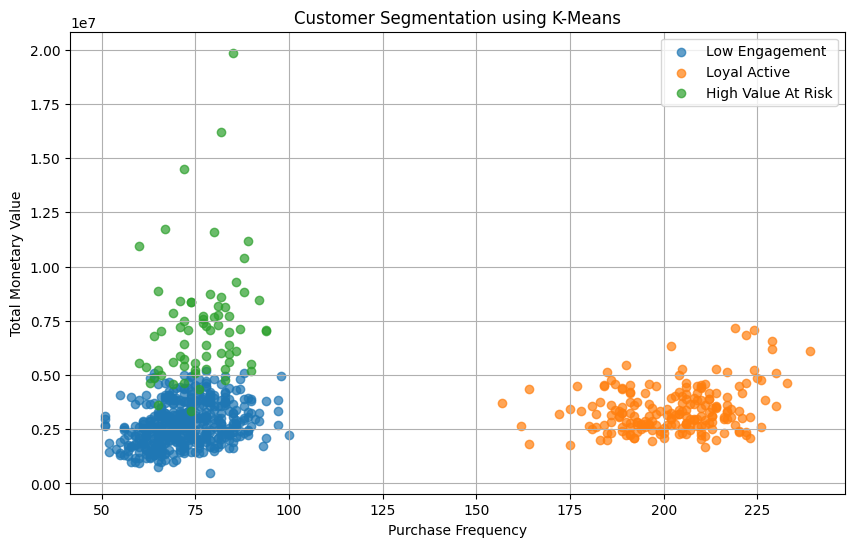

Visualization saved:
✓ visualizations/customer_clusters.png


In [45]:
# Visualize customer segments

plt.figure(figsize=(10, 6))

for cluster in sorted(customer_features["Cluster"].unique()):
    cluster_data = customer_features[
        customer_features["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Frequency"],
        cluster_data["Monetary"],
        label=cluster_labels[cluster],
        alpha=0.7
    )

plt.xlabel("Purchase Frequency")
plt.ylabel("Total Monetary Value")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.grid(True)

# Save BEFORE showing
plt.savefig(
    "visualizations/customer_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization saved:")
print("✓ visualizations/customer_clusters.png")

In [46]:
# Create business-oriented cluster profile

cluster_profile = customer_features.groupby(
    ["Cluster", "Segment"]
).agg(
    Customers=("Customer Name", "count"),
    Avg_Recency_Days=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary_Value=("Monetary", "mean"),
    Avg_Product_Diversity=("Product_Diversity", "mean"),
    Avg_Total_Quantity=("Total_Quantity", "mean"),
    Avg_Order_Value=("Average_Order_Value", "mean")
).reset_index()

# Round numerical values for readability
numeric_columns = cluster_profile.select_dtypes(
    include=["float64", "int64"]
).columns

cluster_profile[numeric_columns] = (
    cluster_profile[numeric_columns].round(2)
)

print("Customer Segment Profile")
print("=" * 80)
display(cluster_profile)

# Save profile
cluster_profile.to_csv(
    "outputs/cluster_profile.csv",
    index=False
)

print("\n✓ outputs/cluster_profile.csv saved")

Customer Segment Profile


,Cluster,Segment,Customers,Avg_Recency_Days,Avg_Frequency,Avg_Monetary_Value,Avg_Product_Diversity,Avg_Total_Quantity,Avg_Order_Value
0,0,Low Engagement,482,487.45,72.33,2748942.63,62.43,6886.96,38079.69
1,1,Loyal Active,200,31.00,202.42,3404379.71,136.58,8371.62,16815.33
2,2,High Value At Risk,69,488.35,76.86,7310908.17,65.67,16218.20,95489.97



✓ outputs/cluster_profile.csv saved


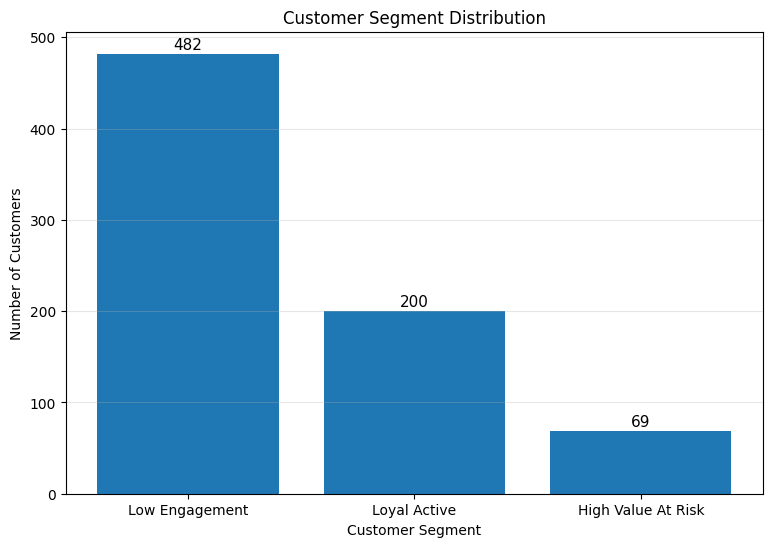

✓ visualizations/customer_segment_distribution.png saved


In [47]:
# Visualize customer segment distribution

segment_counts = (
    customer_features["Segment"]
    .value_counts()
    .reindex([
        "Low Engagement",
        "Loyal Active",
        "High Value At Risk"
    ])
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "visualizations/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ visualizations/customer_segment_distribution.png saved")

In [48]:
# Save final ML model evaluation metrics

final_metrics = pd.DataFrame({
    "Metric": [
        "Number of Customers",
        "Number of Features",
        "Optimal K",
        "Silhouette Score",
        "Low Engagement Customers",
        "Loyal Active Customers",
        "High Value At Risk Customers"
    ],
    "Value": [
        len(customer_features),
        len(features),
        optimal_k,
        0.6599,
        (customer_features["Segment"] == "Low Engagement").sum(),
        (customer_features["Segment"] == "Loyal Active").sum(),
        (customer_features["Segment"] == "High Value At Risk").sum()
    ]
})

final_metrics.to_csv(
    "outputs/model_metrics.csv",
    index=False
)

display(final_metrics)

print("\n✓ outputs/model_metrics.csv saved")

,Metric,Value
0,Number of Customers,751.0000
1,Number of Features,6.0000
2,Optimal K,3.0000
3,Silhouette Score,0.6599
4,Low Engagement Customers,482.0000
5,Loyal Active Customers,200.0000
6,High Value At Risk Customers,69.0000



✓ outputs/model_metrics.csv saved
